In [ ]:
import kagglehub
kmader_skin_cancer_mnist_ham10000_path = kagglehub.dataset_download('kmader/skin-cancer-mnist-ham10000')

print('Data source import complete.')


Data source import complete.


# Set Up

In [ ]:
#The Following cell of code is used everytime FASTAI library is used.
#They tell the notebook to reload any changes made to any libraries used.
#They also ensure that any graphs are plotted are shown in this notebook
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [ ]:
from fastai.vision.all import *
from fastai.metrics import *
import pandas as pd
from pathlib import Path

In [ ]:
csv_path = "/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv"
skin_df = pd.read_csv(csv_path)
skin_df.sort_values(by="image_id")

,lesion_id,image_id,dx,dx_type,age,sex,localization
4349,HAM_0000550,ISIC_0024306,nv,follow_up,45.0,male,trunk
4263,HAM_0003577,ISIC_0024307,nv,follow_up,50.0,male,lower extremity
4217,HAM_0001477,ISIC_0024308,nv,follow_up,55.0,female,trunk
3587,HAM_0000484,ISIC_0024309,nv,follow_up,40.0,male,trunk
1451,HAM_0003350,ISIC_0024310,mel,histo,60.0,male,chest
...,...,...,...,...,...,...,...
1721,HAM_0004304,ISIC_0034316,mel,histo,85.0,male,upper extremity
1888,HAM_0006376,ISIC_0034317,mel,histo,70.0,female,lower extremity
121,HAM_0000344,ISIC_0034318,bkl,histo,55.0,male,trunk
7440,HAM_0000747,ISIC_0034319,nv,histo,30.0,male,trunk


In [ ]:
path = Path('/kaggle/input/skin-cancer-mnist-ham10000') # Changed to the correct absolute path in Kaggle
Path.BASE_PATH = path
path.ls()

(#9) [Path('hmnist_8_8_RGB.csv'),Path('hmnist_28_28_RGB.csv'),Path('HAM10000_images_part_1'),Path('ham10000_images_part_1'),Path('hmnist_8_8_L.csv'),Path('HAM10000_images_part_2'),Path('ham10000_images_part_2'),Path('hmnist_28_28_L.csv'),Path('HAM10000_metadata.csv')]

## Rename Variables

In [ ]:
short_to_full_name_dict = {
    "akiec" : "Bowen's disease", # very early form of skin cancer
    "bcc" : "basal cell carcinoma" , # basal-cell cancer or white skin cancer
    "bkl" : "benign keratosis-like lesions", # non-cancerous skin tumour
    "df" : "dermatofibroma", # non-cancerous rounded bumps
    "mel" : "melanoma", # black skin cancer
    "nv" : "melanocytic nevi", # mole non-cancerous
    "vasc" : "vascular lesions", # skin condition
}

# Get Images from file

In [ ]:
# returns only dx and image id column
img_to_class_dict = skin_df.loc[:, ["image_id", "dx"]]
# returns columns as lists in a dict
img_to_class_dict = img_to_class_dict.to_dict('list')
# returns a dict mapping image id to disease name
img_to_class_dict = {img_id : short_to_full_name_dict[disease] for img_id,disease in zip(img_to_class_dict['image_id'], img_to_class_dict['dx']) }
[x for x in img_to_class_dict.items()][:5]

[('ISIC_0027419', 'benign keratosis-like lesions'),
 ('ISIC_0025030', 'benign keratosis-like lesions'),
 ('ISIC_0026769', 'benign keratosis-like lesions'),
 ('ISIC_0025661', 'benign keratosis-like lesions'),
 ('ISIC_0031633', 'benign keratosis-like lesions')]

In [ ]:
# path.stem returns the filename without suffix
def get_label_from_dict(path):
    return img_to_class_dict[path.stem]

# Constructing a DataBlock

In [ ]:
dblock = DataBlock(
    # Designation the independent and dependent variables
    blocks = (ImageBlock, CategoryBlock),
    # To get a list of those files,and returns a list of all of the images in that path
    get_items = get_image_files,
    # Split our training and validation sets randomly
    splitter = RandomSplitter(valid_pct=0.2, seed=42),
    # We are telling fastai what function to call to create the labels in our dataset, in our case is independet variable
    get_y = get_label_from_dict,
    # DihedralItem all 4 90 deg roatations and for each:
    #2 horizonntal flips -> 8 orientations
    item_tfms=[Resize(448), DihedralItem()],
    # Picks a random scaled crop of an image and resize it to size
    batch_tfms=RandomResizedCrop(size=224, min_scale=0.75, max_scale=1.0))

img_path = "/kaggle/input/skin-cancer-mnist-ham10000"
# create dataloader using img_path
dls = dblock.dataloaders(img_path, bs=64) # bs = batch size

# Display the images

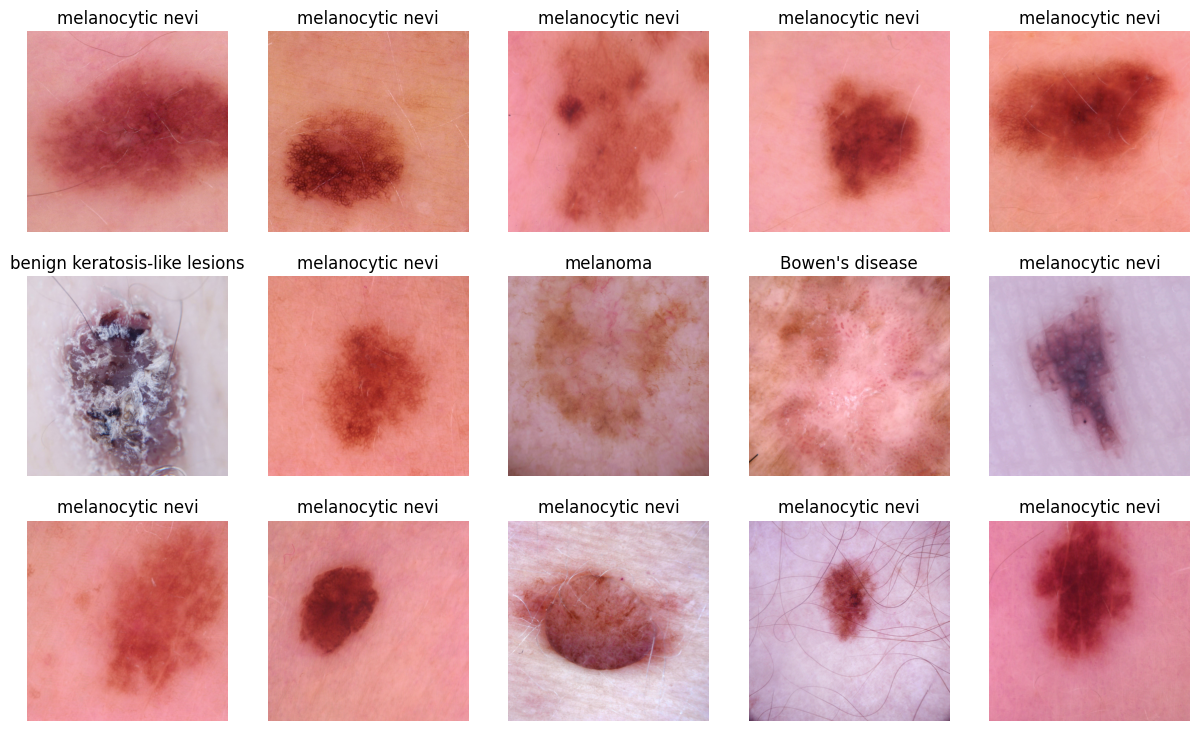

In [ ]:
dls.show_batch(max_n=15)

Observations from these images will be noted below. First, I'll do some more checks to confirm our categories are just "Bowen's disease", 'basal cell carcinoma', 'benign keratosis-like lesions', 'dermatofibroma', 'melanocytic nevi', 'melanoma', 'vascular lesions':

In [ ]:
print(dls.vocab)

["Bowen's disease", 'basal cell carcinoma', 'benign keratosis-like lesions', 'dermatofibroma', 'melanocytic nevi', 'melanoma', 'vascular lesions']


Let's preview our datasets length:

In [ ]:
len(dls.train_ds), len(dls.valid_ds)

(16024, 4006)

# Train a simple model

In [ ]:
learn = vision_learner(dls,
                    resnet18,
                    metrics=accuracy)
learn.fine_tune(4)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 110MB/s]


epoch,train_loss,valid_loss,accuracy,time
0,1.061392,0.698220,0.773090,00:46


epoch,train_loss,valid_loss,accuracy,time
0,0.604309,0.483884,0.826760,00:43
1,0.440388,0.377487,0.865452,00:42
2,0.292717,0.277560,0.904393,00:42
3,0.227315,0.245114,0.911633,00:42


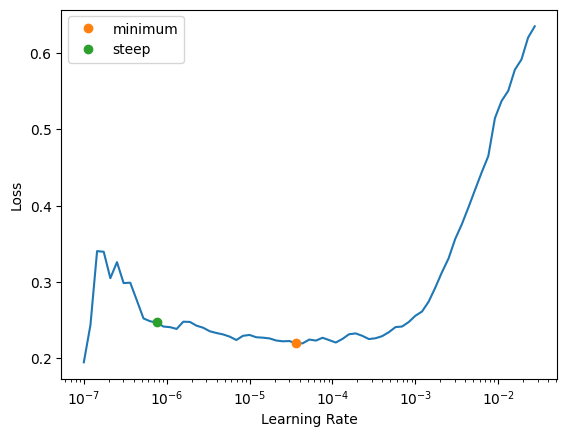

In [ ]:
lr_min,lr_steep = learn.lr_find(suggest_funcs=(minimum, steep))

In [ ]:
print(f"Minimum/10: {lr_min:.2e}, steepest point: {lr_steep:.2e}")

Minimum/10: 3.63e-06, steepest point: 7.59e-07


**train fit_one_cycle for 3 cycles get an idea of how accurate the model would be with resnet34.**

In [ ]:
learn = vision_learner(dls,resnet34, metrics = accuracy)
learn.fit_one_cycle(3,1e-2)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 108MB/s]


epoch,train_loss,valid_loss,accuracy,time
0,0.756296,0.658134,0.771593,00:47
1,0.506212,0.401062,0.853470,00:47
2,0.356873,0.333650,0.875437,00:47


# Unfreezing and Transfer Learning

In [ ]:
learn.unfreeze()

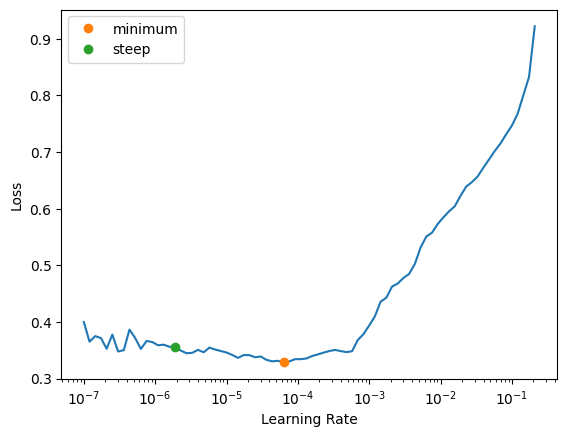

In [ ]:
lr_min,lr_steep = learn.lr_find(suggest_funcs=(minimum, steep))

In [ ]:
print(f"Minimum/10: {lr_min:.2e}, steepest point: {lr_steep:.2e}")

Minimum/10: 6.31e-06, steepest point: 1.91e-06


In [ ]:
learn.fit_one_cycle(30 ,lr_max=slice(1e-4, 1e-2))

epoch,train_loss,valid_loss,accuracy,time
0,0.334491,0.339542,0.883425,00:55
1,0.379308,0.439685,0.845981,00:55
2,0.402562,0.486207,0.832002,00:55
3,0.410669,0.444444,0.841488,00:55
4,0.438301,0.652470,0.799301,00:55
5,0.432476,0.562250,0.809036,00:55
6,0.387007,0.500367,0.830504,00:55
7,0.367909,0.566874,0.813280,00:55
8,0.349442,0.340877,0.876435,00:55
9,0.323103,0.322664,0.889416,00:55


<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

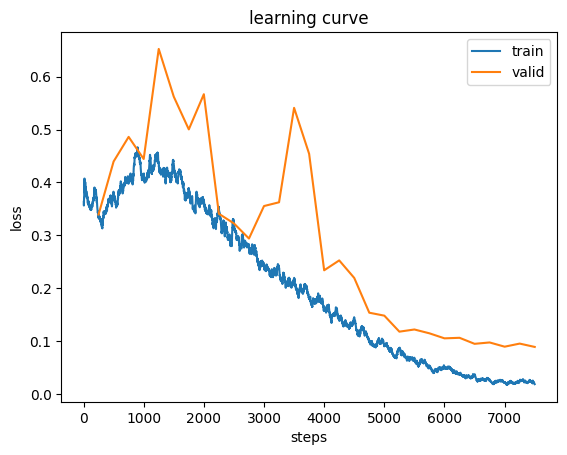

In [ ]:
learn.recorder.plot_loss()

### saving the model

In [ ]:
learn.save('model1')

Path('models/model1.pth')

# Model Interpretation

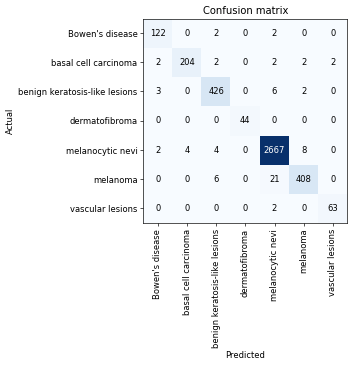

In [ ]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(6,6), dpi=60)

# Top 6 losses

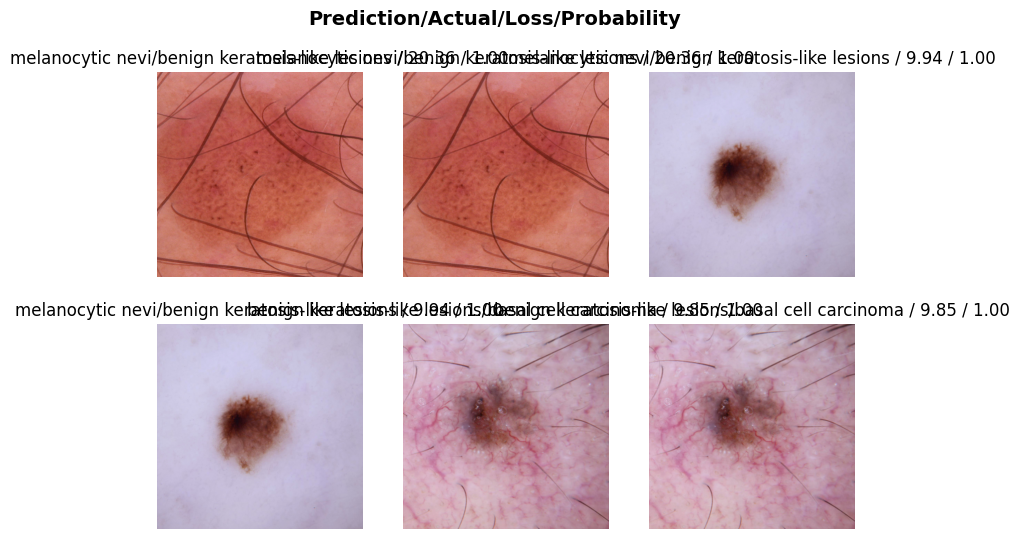

In [ ]:
interp.plot_top_losses(6, nrows=2)

# Reference

[HAM10000 Vision ResNet18](https://www.kaggle.com/code/leonblum/ham10000-vision-resnet18-97-7-accuracy)

#### I hope you like it